# Auswirkung einer konstanten Zeitverschiebung auf die Phase
Zu sehen sind drei Sinussignale mit den Frequenzen 1 Hz (schwarz), 2 Hz (rot) und 4 Hz (blau). Diese werden nun um $t_0$ verschoben (gepunktete Linie). Der rechte Graph zeigt die resultierende Phase $\phi$ als Vielfaches von $pi$.  
Eine Zeitverschiebung um $t_0$ führt zu einer linearen Phasenverschiebung, wie in der Phasendarstellung sichtbar ist. Umgekehrt kann aus einem linearen Phasengang eines Systems auf eine konstante Zeitverschiebung des Signals rückgeschlossen werden, d.h. es treten keine phasenbedingten Verzerrungen durch das System im Signal auf. Für viele Anwendungen ist ein solches Systemverhalten erwünscht.  

FloatSlider(value=0.0, description='$t_0$', max=0.5, step=0.125)

Output()

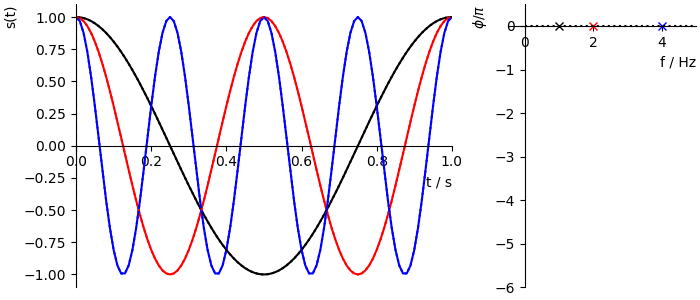

In [12]:
"""
Beispielscript im Matlab-Style (Import und tw. Wrapping auf Matlab-Wording), 
Kernfunktionalität für Studierende mit Matlaberfahrung unmittelbar les- und verstehbar

(c) Benno Dömer | HS Pforzheim 2022 

"""
import platform
if platform.system() == "Emscripten": # running in JupyterLite
    %pip install -r runtime-requirements.txt

# 'widget' für interaktive Plots
%matplotlib widget 

# Import so, dass möglichst viele Funktionen "wie in Matlab" zur Verfügung stehen:
from numpy import (pi, log10, exp, sqrt, sin, cos, tan, angle, arange, linspace, zeros, ones, array) # numpy für's Rechnen, bei Bedarf anpassen
from matplotlib.pyplot import (figure, plot, stem, legend, text, show,
                               grid, xlabel, ylabel, subplot, legend, title, clf, cla, xlim, ylim) # matpotlib für's  Plotten, bei Bedarf anpassen
from matplotlib.pyplot import fill_between as area # Beispiel für eine Mapping auf Matlab-Bezeichnung
import ipywidgets as widgets # interaktive Controls wie Slider, Dropdowns etc.

fig1 = figure(figsize=(8, 4), dpi=100, 
       layout='constrained',num=' ') # bei Bedarf anpassen, Achtung Tablet: Nicht über 7 Breite; Titel hinter "num", hier Leerzeichen

def myplotstyle(ax): # Hilfsfunktion, hübscht den Plot etwas auf
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data',0))
    ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data',0))
    
# Plotbefehle werden in eine Funktion verpackt, die dann bei Interaktionen aufgerufen wird. Hier ist die Kernfunktionalität
# In Python wird statt mit Klammern oder Schlüsselwörtern wie "end" mit Einrückungen gearbeitet
def plotdata(t0):
    ax1 = subplot(1,3,(1,2)) 
    cla()
    x = arange(-0.5,1.25,0.01)
    f0=1;
    #y = 0.5*x**2*exp(-x)
    #x = arange(-5,5,0.01)
    #y = sinc(x)
    plot(x, cos(2*pi*f0*x),'k',label=r'$s(t)=cos(2\pi \cdot f_0 \cdot t)$')
    plot(x, cos(2*pi*f0*2*x),'r',label=r'$s(t)=cos(2\pi \cdot 2  \cdot f_0 \cdot t)$')
    plot(x, cos(2*pi*f0*4*x),'b',label=r'$s(t)=cos(2\pi \cdot  \cdot4 f_0 \cdot t)$')
    
    xs=x-t0;
    plot(x, cos(2*pi*f0*xs),'k:',label=r'$s(t)=cos(2\pi \cdot f_0  \cdot (t-t_0)$')
    plot(x, cos(2*pi*f0*2*xs),'r:',label=r'$s(t)=cos(2\pi  \cdot 2  \cdot f_0  \cdot(t-t_0)$')
    plot(x, cos(2*pi*f0*4*xs),'b:',label=r'$s(t)=cos(2\pi  \cdot 4  \cdot f_0  \cdot (t-t_0)$')

    plot([t0,t0],[-1,1],'--k')
    
    #plot(x,y,'-r',pi*x,y,'-k')
    xlabel('t / s',loc='right') # Use "$...$" for LaTex expressions
    ylabel('s(t)',loc='top') 
    #title('Titel')
    xlim(0,1)
    #grid()
    myplotstyle(ax1) # aufhübschen
    #ax1.legend(loc=1)
    
    ax2 = subplot(1,3,3) # Plot im Zeitbereich
    cla()
    f = array([0,1,2,4,5]);
    phi = -t0*f0*f*2 # *pi
    plot(1,-t0*f0*2,'xk',2,-t0*f0*4,'xr',4,-t0*f0*8,'xb')
    plot(f,phi,':k')
    xlim(-0.5,5)
    ylim(-6,0.5)
    xlabel('f / Hz',loc='right') # Use "$...$" for LaTex expressions
    ylabel(r'$\phi / \pi$',loc='top') 
    myplotstyle(ax2)
    fig1.canvas.draw()
    
# Interaktion: 
# Definition von Controls: 
t0slider  = widgets.FloatSlider(min=0, max=0.5, step=0.125, value=0, continuous_update=True, description=r'$t_0$')

#Verknüpfen mit Callback
out = widgets.interactive_output(plotdata, { 't0': t0slider}) 
#Anzeigen
display(t0slider,out)
figure(fig1)
show()